# Predicting March Madness success with KenPom data


# Predicting March Madness Success Using KenPom Analytics

**Author:** Sam Olson

**Tools:** Python, pandas, matplotlib, scikit-learn, statsmodels

**Techniques:** Data cleaning, exploratory analysis, linear regression, feature importance

**Dataset:** KenPom NCAA Division I Basketball Statistics (2014–2024)

### In the world of NCAA Men’s Division 1 college basketball, playing in the March Madness tournament at the end of the season is the ultimate goal. 68 out of the roughly 360 total teams are selected each season, and play a single-elimination tournament to determine the National Champion. The matchups are laid on in a bracket, and it has become very popular for people to fill out a bracket predicting who will win each game. Due to the volume of games across every round and the fact that many lower-seeded teams beat higher-seeded teams every year, it is virtually impossible to predict every game correctly (in fact, it has never happened and almost certainly never will). 

### In the analysis below, I will attempt to predict how many wins teams will earn in March Madness based on statistics from Ken Pomeroy's college basketball analytics site (KenPom.com) using linear regression. KenPom uses "four factors" to determine how good teams have performed across the entire season and produce a ranking of all teams in Division 1. These factors are effective field goal percentage, turnover percentage, offensive rebounding percentage, and free throw rate. These factors are present for both offense and defense in basketball, so there will be 8 total predictor variables in the model. I will be using the 2014-2024 March Madness tournaments (excluding 2020 which was cancelled due to Covid) as the observations to build and test the model.

### I have two research questions for this analysis:
###     1) How well can KenPom's four factors data predict how many games a team will win in March Madness?
###     2) Which of the four factors are most important in predicting March Madness success?

# Note that the below cell will produce an error due to the statsmodels package

In [2]:
# Import packages - note that the statsmodels package will produce a warning
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

/usr/local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
/usr/local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


# Explanation of the data

- The 'offense_20xx' files contain the offensive four factors statistics for each Division 1 team for the given season.
<br>
- The 'defense_20xx' files contain the defensive four factors statistics for each Division 1 team for the given season.
<br>
- The 'summary_20xx' files contain summary data for each Division 1 team for the given season. These files will allow me to determine which teams participated in March Madness.
<br>
- The 'wins' file contains each team that participated in March Madness in any season from 2014-2024, along with the number of games that they won.

I will provide further details on the contents of the data as the analysis continues.

In [3]:
# import the data
offense_2014 = pd.read_csv('offense14.csv')
offense_2015 = pd.read_csv('offense15.csv')
offense_2016 = pd.read_csv('offense16.csv')
offense_2017 = pd.read_csv('offense17.csv')
offense_2018 = pd.read_csv('offense18.csv')
offense_2019 = pd.read_csv('offense19.csv')
offense_2021 = pd.read_csv('offense21.csv')
offense_2022 = pd.read_csv('offense22.csv')
offense_2023 = pd.read_csv('offense23.csv')
offense_2024 = pd.read_csv('offense24.csv')
defense_2014 = pd.read_csv('defense14.csv')
defense_2015 = pd.read_csv('defense15.csv')
defense_2016 = pd.read_csv('defense16.csv')
defense_2017 = pd.read_csv('defense17.csv')
defense_2018 = pd.read_csv('defense18.csv')
defense_2019 = pd.read_csv('defense19.csv')
defense_2021 = pd.read_csv('defense21.csv')
defense_2022 = pd.read_csv('defense22.csv')
defense_2023 = pd.read_csv('defense23.csv')
defense_2024 = pd.read_csv('defense24.csv')
summary_2014 = pd.read_csv('summary14_pt_csv.csv')
summary_2015 = pd.read_csv('summary15_pt_csv.csv')
summary_2016 = pd.read_csv('summary16_pt_csv.csv')
summary_2017 = pd.read_csv('summary17_pt_csv.csv')
summary_2018 = pd.read_csv('summary18_pt_csv.csv')
summary_2019 = pd.read_csv('summary19_pt_csv.csv')
summary_2021 = pd.read_csv('summary21_pt_csv.csv')
summary_2022 = pd.read_csv('summary22_pt_csv.csv')
summary_2023 = pd.read_csv('summary23_pt_csv.csv')
summary_2024 = pd.read_csv('summary24_pt_csv.csv')
wins = pd.read_csv('Wins_csv.csv')

# Offense datasets
Let's start by looking at one of the offense datasets. We can see that it contains the season, the team name, and each of the four factors:
- eFGPct is effective field goal percentage.
  - This is the percentage of shots made by the team, with three-pointers weighted 50% more than two-pointers.
- TOPct is turnover percentage.
  - This is the percentage of a team's possessions that they turn the ball over.
- ORPct is offensive rebounding percentage.
  - This is the percentage of rebounds that the team gets from their own missed shots.
- FTRate is free throw rate.
  - This measures a team's ability to get to the free throw line, where it is easier to score points.

In addition to the raw four factors, there are also rankings for each of the four factors. This captures where the team ranks among all Division 1 teams for that particular factor. These rankings will not be used and will be discarded further along in the analysis.
<br>
<br>
Note that there are 362 observations - this is the total number of Division 1 teams in the 2024 season. Since I only care about the 68 teams who made March Madness, I will strip out unnecessary rows further along in the analysis.

In [4]:
print(f"Number of observations: {len(offense_2024)}")
display(offense_2024.head(5))

Number of observations: 362


,Season,TeamName,eFGPct,RankeFGPct,TOPct,RankTOPct,ORPct,RankORPct,FTRate,RankFTRate
0,2024,Abilene Christian,47.148090,303,17.705691,221,25.935162,280,37.938252,53
1,2024,Air Force,53.834165,46,18.782187,295,23.834746,322,29.613466,267
2,2024,Akron,51.630144,120,16.962665,178,29.177958,160,32.709781,179
3,2024,Alabama,56.312919,10,15.918156,98,34.914752,25,35.318792,106
4,2024,Alabama A&M,45.881126,338,22.431094,358,31.851253,85,47.236705,2


# Defense datasets
The defense datasets are identical to the offense datasets, but measure how good each team performs defensively instead of offensively.

In [5]:
print(f"Number of observations: {len(defense_2024)}")
display(defense_2024.head(5))

Number of observations: 362


,Season,TeamName,eFGPct,RankeFGPct,TOPct,RankTOPct,ORPct,RankORPct,FTRate,RankFTRate
0,2024,Abilene Christian,51.669359,248,20.253272,32,30.462375,244,39.903069,324
1,2024,Air Force,54.169221,338,17.570433,135,31.461864,298,39.055794,311
2,2024,Akron,49.036918,94,16.736496,192,25.479930,43,29.373997,94
3,2024,Alabama,49.659430,127,15.191300,296,31.046431,277,38.825032,307
4,2024,Alabama A&M,49.079602,96,19.532917,44,32.702916,325,45.174129,353


# Summary datasets
The summary datasets also contain the season and team name, along with summary information for each team.
<br>
<br>
The key column here is 'seed'. Teams in March Madness can receive any seed from 1-16, with 1 being the best and 16 being the worst. This column indicates what seed each team received, so if there is any number in that column that means the team made March Madness. If it is NaN, the team didn't make March Madness.
<br>
<br>
For example, note that Akron has a 14 in the 'seed' column, so they made March Madness and received a 14 seed. Abilene Christian shows NaN, so they did not make March Madness in 2024.

In [6]:
print(f"Number of observations: {len(summary_2024)}")
display(summary_2024.head(5))

Number of observations: 362


,Season,TeamName,Tempo,RankTempo,AdjTempo,RankAdjTempo,OE,RankOE,AdjOE,RankAdjOE,DE,RankDE,AdjDE,RankAdjDE,AdjEM,RankAdjEM,seed
0,2024,Abilene Christian,70.6234,63,68.4072,117,99.2921,294,101.5090,260,103.0420,121,105.696,164,-4.18638,220,NaN
1,2024,Air Force,63.4044,354,61.7838,359,103.4510,220,105.9020,182,113.9820,346,113.089,322,-7.18660,260,NaN
2,2024,Akron,66.7904,274,65.9084,267,107.8170,122,106.9850,163,99.6876,47,102.050,97,4.93477,116,14.0
3,2024,Alabama,74.1625,7,72.6437,10,121.7120,2,125.6040,2,108.0310,254,103.121,112,22.48230,13,4.0
4,2024,Alabama A&M,71.7614,38,70.2920,47,95.5025,333,93.5544,347,104.7790,178,109.002,237,-15.44810,327,NaN


# Wins dataset
This dataset only contains the season, the team name, the seed that the team received in March Madness, and the number of games won in March Madness that season.
<br>
<br>
The team that wins March Madness needs to win 6 games, so the number of wins ranges from 0-6.
<br>
<br>
Note that there are 680 observations - this is due to 68 teams per season, for 10 seasons.
<br>
<br>
Also note that teams can appear multiple times in this dataset if they made March Madness in multiple seasons. For example, Villanova made March Madness in 8 of the 10 seasons from 2014-2024, so they have 8 records. Unfortunately, Georgia Tech only appeared once in that time frame.

In [7]:
print(f"Number of observations: {len(wins)}")
print(f"Villanova appears {wins['TeamName'].value_counts()['Villanova']} times")
print(f"Georgia Tech appears {wins['TeamName'].value_counts()['Georgia Tech']} time")
display(wins.head(5))

Number of observations: 680
Villanova appears 8 times
Georgia Tech appears 1 time


,Season,TeamName,seed,Wins
0,2024,Akron,14,0
1,2024,Alabama,4,4
2,2024,Arizona,2,2
3,2024,Auburn,4,0
4,2024,Baylor,3,1


# Data cleaning: rename columns
Since the names of the columns in the offense and defense datasets are identical, I will rename the columns with a suffix to differentiate them. Offensive statistics will end in '_o' and defensive statistics will end in '_d'.
<br>
<br>
This is also helpful because the column naming convention for the four factors changed after 2016. For example, from through 2016, the effective field goal percentage column was labeled as 'eFG_Pct', while after 2016 it was labeled as 'eFGPct' with no underscore. This cleaning exercise will help to standardize the column names across seasons, as the datasets will be joined further along in the analysis.

In [8]:
# rename columns
defense_2024_2 = defense_2024.rename(columns={'Season': 'Season_d', 'eFGPct': 'eFGPct_d', 'RankeFGPct': 'RankeFGPct_d', 'TOPct': 'TOPct_d', 'RankTOPct': 'RankTOPct_d', 'ORPct': 'ORPct_d', 'RankORPct': 'RankORPct_d', 'FTRate': 'FTRate_d', 'RankFTRate': 'RankFTRate_d'})
offense_2024_2 = offense_2024.rename(columns={'Season': 'Season_o', 'eFGPct': 'eFGPct_o', 'RankeFGPct': 'RankeFGPct_o', 'TOPct': 'TOPct_o', 'RankTOPct': 'RankTOPct_o', 'ORPct': 'ORPct_o', 'RankORPct': 'RankORPct_o', 'FTRate': 'FTRate_o', 'RankFTRate': 'RankFTRate_o'})
defense_2023_2 = defense_2023.rename(columns={'Season': 'Season_d', 'eFGPct': 'eFGPct_d', 'RankeFGPct': 'RankeFGPct_d', 'TOPct': 'TOPct_d', 'RankTOPct': 'RankTOPct_d', 'ORPct': 'ORPct_d', 'RankORPct': 'RankORPct_d', 'FTRate': 'FTRate_d', 'RankFTRate': 'RankFTRate_d'})
offense_2023_2 = offense_2023.rename(columns={'Season': 'Season_o', 'eFGPct': 'eFGPct_o', 'RankeFGPct': 'RankeFGPct_o', 'TOPct': 'TOPct_o', 'RankTOPct': 'RankTOPct_o', 'ORPct': 'ORPct_o', 'RankORPct': 'RankORPct_o', 'FTRate': 'FTRate_o', 'RankFTRate': 'RankFTRate_o'})
defense_2022_2 = defense_2022.rename(columns={'Season': 'Season_d', 'eFGPct': 'eFGPct_d', 'RankeFGPct': 'RankeFGPct_d', 'TOPct': 'TOPct_d', 'RankTOPct': 'RankTOPct_d', 'ORPct': 'ORPct_d', 'RankORPct': 'RankORPct_d', 'FTRate': 'FTRate_d', 'RankFTRate': 'RankFTRate_d'})
offense_2022_2 = offense_2022.rename(columns={'Season': 'Season_o', 'eFGPct': 'eFGPct_o', 'RankeFGPct': 'RankeFGPct_o', 'TOPct': 'TOPct_o', 'RankTOPct': 'RankTOPct_o', 'ORPct': 'ORPct_o', 'RankORPct': 'RankORPct_o', 'FTRate': 'FTRate_o', 'RankFTRate': 'RankFTRate_o'})
defense_2021_2 = defense_2021.rename(columns={'Season': 'Season_d', 'eFGPct': 'eFGPct_d', 'RankeFGPct': 'RankeFGPct_d', 'TOPct': 'TOPct_d', 'RankTOPct': 'RankTOPct_d', 'ORPct': 'ORPct_d', 'RankORPct': 'RankORPct_d', 'FTRate': 'FTRate_d', 'RankFTRate': 'RankFTRate_d'})
offense_2021_2 = offense_2021.rename(columns={'Season': 'Season_o', 'eFGPct': 'eFGPct_o', 'RankeFGPct': 'RankeFGPct_o', 'TOPct': 'TOPct_o', 'RankTOPct': 'RankTOPct_o', 'ORPct': 'ORPct_o', 'RankORPct': 'RankORPct_o', 'FTRate': 'FTRate_o', 'RankFTRate': 'RankFTRate_o'})
defense_2019_2 = defense_2019.rename(columns={'Season': 'Season_d', 'eFGPct': 'eFGPct_d', 'RankeFGPct': 'RankeFGPct_d', 'TOPct': 'TOPct_d', 'RankTOPct': 'RankTOPct_d', 'ORPct': 'ORPct_d', 'RankORPct': 'RankORPct_d', 'FTRate': 'FTRate_d', 'RankFTRate': 'RankFTRate_d'})
offense_2019_2 = offense_2019.rename(columns={'Season': 'Season_o', 'eFGPct': 'eFGPct_o', 'RankeFGPct': 'RankeFGPct_o', 'TOPct': 'TOPct_o', 'RankTOPct': 'RankTOPct_o', 'ORPct': 'ORPct_o', 'RankORPct': 'RankORPct_o', 'FTRate': 'FTRate_o', 'RankFTRate': 'RankFTRate_o'})
defense_2018_2 = defense_2018.rename(columns={'Season': 'Season_d', 'eFGPct': 'eFGPct_d', 'RankeFGPct': 'RankeFGPct_d', 'TOPct': 'TOPct_d', 'RankTOPct': 'RankTOPct_d', 'ORPct': 'ORPct_d', 'RankORPct': 'RankORPct_d', 'FTRate': 'FTRate_d', 'RankFTRate': 'RankFTRate_d'})
offense_2018_2 = offense_2018.rename(columns={'Season': 'Season_o', 'eFGPct': 'eFGPct_o', 'RankeFGPct': 'RankeFGPct_o', 'TOPct': 'TOPct_o', 'RankTOPct': 'RankTOPct_o', 'ORPct': 'ORPct_o', 'RankORPct': 'RankORPct_o', 'FTRate': 'FTRate_o', 'RankFTRate': 'RankFTRate_o'})
defense_2017_2 = defense_2017.rename(columns={'Season': 'Season_d', 'eFGPct': 'eFGPct_d', 'RankeFGPct': 'RankeFGPct_d', 'TOPct': 'TOPct_d', 'RankTOPct': 'RankTOPct_d', 'ORPct': 'ORPct_d', 'RankORPct': 'RankORPct_d', 'FTRate': 'FTRate_d', 'RankFTRate': 'RankFTRate_d'})
offense_2017_2 = offense_2017.rename(columns={'Season': 'Season_o', 'eFGPct': 'eFGPct_o', 'RankeFGPct': 'RankeFGPct_o', 'TOPct': 'TOPct_o', 'RankTOPct': 'RankTOPct_o', 'ORPct': 'ORPct_o', 'RankORPct': 'RankORPct_o', 'FTRate': 'FTRate_o', 'RankFTRate': 'RankFTRate_o'})
defense_2016_2 = defense_2016.rename(columns={'Season': 'Season_d', 'eFG_Pct': 'eFGPct_d', 'RankeFG_Pct': 'RankeFGPct_d', 'TO_Pct': 'TOPct_d', 'RankTO_Pct': 'RankTOPct_d', 'OR_Pct': 'ORPct_d', 'RankOR_Pct': 'RankORPct_d', 'FT_Rate': 'FTRate_d', 'RankFT_Rate': 'RankFTRate_d'})
offense_2016_2 = offense_2016.rename(columns={'Season': 'Season_o', 'eFG_Pct': 'eFGPct_o', 'RankeFG_Pct': 'RankeFGPct_o', 'TO_Pct': 'TOPct_o', 'RankTO_Pct': 'RankTOPct_o', 'OR_Pct': 'ORPct_o', 'RankOR_Pct': 'RankORPct_o', 'FT_Rate': 'FTRate_o', 'RankFT_Rate': 'RankFTRate_o'})
defense_2015_2 = defense_2015.rename(columns={'Season': 'Season_d', 'eFG_Pct': 'eFGPct_d', 'RankeFG_Pct': 'RankeFGPct_d', 'TO_Pct': 'TOPct_d', 'RankTO_Pct': 'RankTOPct_d', 'OR_Pct': 'ORPct_d', 'RankOR_Pct': 'RankORPct_d', 'FT_Rate': 'FTRate_d', 'RankFT_Rate': 'RankFTRate_d'})
offense_2015_2 = offense_2015.rename(columns={'Season': 'Season_o', 'eFG_Pct': 'eFGPct_o', 'RankeFG_Pct': 'RankeFGPct_o', 'TO_Pct': 'TOPct_o', 'RankTO_Pct': 'RankTOPct_o', 'OR_Pct': 'ORPct_o', 'RankOR_Pct': 'RankORPct_o', 'FT_Rate': 'FTRate_o', 'RankFT_Rate': 'RankFTRate_o'})
defense_2014_2 = defense_2014.rename(columns={'Season': 'Season_d', 'eFG_Pct': 'eFGPct_d', 'RankeFG_Pct': 'RankeFGPct_d', 'TO_Pct': 'TOPct_d', 'RankTO_Pct': 'RankTOPct_d', 'OR_Pct': 'ORPct_d', 'RankOR_Pct': 'RankORPct_d', 'FT_Rate': 'FTRate_d', 'RankFT_Rate': 'RankFTRate_d'})
offense_2014_2 = offense_2014.rename(columns={'Season': 'Season_o', 'eFG_Pct': 'eFGPct_o', 'RankeFG_Pct': 'RankeFGPct_o', 'TO_Pct': 'TOPct_o', 'RankTO_Pct': 'RankTOPct_o', 'OR_Pct': 'ORPct_o', 'RankOR_Pct': 'RankORPct_o', 'FT_Rate': 'FTRate_o', 'RankFT_Rate': 'RankFTRate_o'})

# display example of dataset
display(offense_2024_2.head(5))

,Season_o,TeamName,eFGPct_o,RankeFGPct_o,TOPct_o,RankTOPct_o,ORPct_o,RankORPct_o,FTRate_o,RankFTRate_o
0,2024,Abilene Christian,47.148090,303,17.705691,221,25.935162,280,37.938252,53
1,2024,Air Force,53.834165,46,18.782187,295,23.834746,322,29.613466,267
2,2024,Akron,51.630144,120,16.962665,178,29.177958,160,32.709781,179
3,2024,Alabama,56.312919,10,15.918156,98,34.914752,25,35.318792,106
4,2024,Alabama A&M,45.881126,338,22.431094,358,31.851253,85,47.236705,2


# Data cleaning: combine summary, offense, defense
In order to run a linear regression model, I will need one dataset. This means that all of the individual datasets I have imported need to be joined together.
<br>
<br>
The first step is to combine the summary, offense, and defense datasets together for each season. I used an outer join to ensure that all observations from each dataset remained in the combined dataset.
<br>
<br>
Since each team only appears once in each season, I was able to join using the team name as the key.
<br>
<br>
The result is one dataset for each season that contains all of the columns from the summary, offense, and defense datasets.

In [9]:
# combine summary, offense, and defense for each season - join on team name
combined_2024 = summary_2024.merge(offense_2024_2, on='TeamName', how='outer').merge(defense_2024_2, on='TeamName', how='outer')
combined_2023 = summary_2023.merge(offense_2023_2, on='TeamName', how='outer').merge(defense_2023_2, on='TeamName', how='outer')
combined_2022 = summary_2022.merge(offense_2022_2, on='TeamName', how='outer').merge(defense_2022_2, on='TeamName', how='outer')
combined_2021 = summary_2021.merge(offense_2021_2, on='TeamName', how='outer').merge(defense_2021_2, on='TeamName', how='outer')
combined_2019 = summary_2019.merge(offense_2019_2, on='TeamName', how='outer').merge(defense_2019_2, on='TeamName', how='outer')
combined_2018 = summary_2018.merge(offense_2018_2, on='TeamName', how='outer').merge(defense_2018_2, on='TeamName', how='outer')
combined_2017 = summary_2017.merge(offense_2017_2, on='TeamName', how='outer').merge(defense_2017_2, on='TeamName', how='outer')
combined_2016 = summary_2016.merge(offense_2016_2, on='TeamName', how='outer').merge(defense_2016_2, on='TeamName', how='outer')
combined_2015 = summary_2015.merge(offense_2015_2, on='TeamName', how='outer').merge(defense_2015_2, on='TeamName', how='outer')
combined_2014 = summary_2014.merge(offense_2014_2, on='TeamName', how='outer').merge(defense_2014_2, on='TeamName', how='outer')

# display example of dataset
display(combined_2024.head(5))

,Season,TeamName,Tempo,RankTempo,AdjTempo,RankAdjTempo,OE,RankOE,AdjOE,RankAdjOE,...,RankFTRate_o,Season_d,eFGPct_d,RankeFGPct_d,TOPct_d,RankTOPct_d,ORPct_d,RankORPct_d,FTRate_d,RankFTRate_d
0,2024,Abilene Christian,70.6234,63,68.4072,117,99.2921,294,101.5090,260,...,53,2024,51.669359,248,20.253272,32,30.462375,244,39.903069,324
1,2024,Air Force,63.4044,354,61.7838,359,103.4510,220,105.9020,182,...,267,2024,54.169221,338,17.570433,135,31.461864,298,39.055794,311
2,2024,Akron,66.7904,274,65.9084,267,107.8170,122,106.9850,163,...,179,2024,49.036918,94,16.736496,192,25.479930,43,29.373997,94
3,2024,Alabama,74.1625,7,72.6437,10,121.7120,2,125.6040,2,...,106,2024,49.659430,127,15.191300,296,31.046431,277,38.825032,307
4,2024,Alabama A&M,71.7614,38,70.2920,47,95.5025,333,93.5544,347,...,2,2024,49.079602,96,19.532917,44,32.702916,325,45.174129,353


# Data cleaning: drop unnecessary columns
As mentioned earlier, I will not be using the 'rank' columns from any of the datasets in the linear regression model - only the raw statistics themselves.
<br>
<br>
I will also not be using any of the columns from the summary dataset other than 'seed'.
<br>
<br>
Because of this, I dropped the unnecessary columns from each of the combined datasets. After combining, note that the only remaining columns are the season, the team name, the seed, and each of the offensive and defensive four factors.

In [10]:
# drop unnecessary columns
combined_2024_2 = combined_2024.drop(['Tempo', 'RankTempo', 'AdjTempo', 'RankAdjTempo', 'OE', 'RankOE', 'AdjOE', 'RankAdjOE', 'DE', 'RankDE', 'AdjDE', 'RankAdjDE', 'AdjEM', 'RankAdjEM', 'Season_o', 'RankeFGPct_o', 'RankTOPct_o', 'RankORPct_o', 'RankFTRate_o', 'Season_d', 'RankeFGPct_d', 'RankTOPct_d', 'RankORPct_d', 'RankFTRate_d'], axis=1)
combined_2023_2 = combined_2023.drop(['Tempo', 'RankTempo', 'AdjTempo', 'RankAdjTempo', 'OE', 'RankOE', 'AdjOE', 'RankAdjOE', 'DE', 'RankDE', 'AdjDE', 'RankAdjDE', 'AdjEM', 'RankAdjEM', 'Season_o', 'RankeFGPct_o', 'RankTOPct_o', 'RankORPct_o', 'RankFTRate_o', 'Season_d', 'RankeFGPct_d', 'RankTOPct_d', 'RankORPct_d', 'RankFTRate_d'], axis=1)
combined_2022_2 = combined_2022.drop(['Tempo', 'RankTempo', 'AdjTempo', 'RankAdjTempo', 'OE', 'RankOE', 'AdjOE', 'RankAdjOE', 'DE', 'RankDE', 'AdjDE', 'RankAdjDE', 'AdjEM', 'RankAdjEM', 'Season_o', 'RankeFGPct_o', 'RankTOPct_o', 'RankORPct_o', 'RankFTRate_o', 'Season_d', 'RankeFGPct_d', 'RankTOPct_d', 'RankORPct_d', 'RankFTRate_d'], axis=1)
combined_2021_2 = combined_2021.drop(['Tempo', 'RankTempo', 'AdjTempo', 'RankAdjTempo', 'OE', 'RankOE', 'AdjOE', 'RankAdjOE', 'DE', 'RankDE', 'AdjDE', 'RankAdjDE', 'AdjEM', 'RankAdjEM', 'Season_o', 'RankeFGPct_o', 'RankTOPct_o', 'RankORPct_o', 'RankFTRate_o', 'Season_d', 'RankeFGPct_d', 'RankTOPct_d', 'RankORPct_d', 'RankFTRate_d'], axis=1)
combined_2019_2 = combined_2019.drop(['Tempo', 'RankTempo', 'AdjTempo', 'RankAdjTempo', 'OE', 'RankOE', 'AdjOE', 'RankAdjOE', 'DE', 'RankDE', 'AdjDE', 'RankAdjDE', 'AdjEM', 'RankAdjEM', 'Season_o', 'RankeFGPct_o', 'RankTOPct_o', 'RankORPct_o', 'RankFTRate_o', 'Season_d', 'RankeFGPct_d', 'RankTOPct_d', 'RankORPct_d', 'RankFTRate_d'], axis=1)
combined_2018_2 = combined_2018.drop(['Tempo', 'RankTempo', 'AdjTempo', 'RankAdjTempo', 'OE', 'RankOE', 'AdjOE', 'RankAdjOE', 'DE', 'RankDE', 'AdjDE', 'RankAdjDE', 'AdjEM', 'RankAdjEM', 'Season_o', 'RankeFGPct_o', 'RankTOPct_o', 'RankORPct_o', 'RankFTRate_o', 'Season_d', 'RankeFGPct_d', 'RankTOPct_d', 'RankORPct_d', 'RankFTRate_d'], axis=1)
combined_2017_2 = combined_2017.drop(['Tempo', 'RankTempo', 'AdjTempo', 'RankAdjTempo', 'OE', 'RankOE', 'AdjOE', 'RankAdjOE', 'DE', 'RankDE', 'AdjDE', 'RankAdjDE', 'AdjEM', 'RankAdjEM', 'Season_o', 'RankeFGPct_o', 'RankTOPct_o', 'RankORPct_o', 'RankFTRate_o', 'Season_d', 'RankeFGPct_d', 'RankTOPct_d', 'RankORPct_d', 'RankFTRate_d'], axis=1)
combined_2016_2 = combined_2016.drop(['Tempo', 'RankTempo', 'AdjTempo', 'RankAdjTempo', 'OE', 'RankOE', 'AdjOE', 'RankAdjOE', 'DE', 'RankDE', 'AdjDE', 'RankAdjDE', 'AdjEM', 'RankAdjEM', 'Season_o', 'RankeFGPct_o', 'RankTOPct_o', 'RankORPct_o', 'RankFTRate_o', 'Season_d', 'RankeFGPct_d', 'RankTOPct_d', 'RankORPct_d', 'RankFTRate_d'], axis=1)
combined_2015_2 = combined_2015.drop(['Tempo', 'RankTempo', 'AdjTempo', 'RankAdjTempo', 'OE', 'RankOE', 'AdjOE', 'RankAdjOE', 'DE', 'RankDE', 'AdjDE', 'RankAdjDE', 'AdjEM', 'RankAdjEM', 'Season_o', 'RankeFGPct_o', 'RankTOPct_o', 'RankORPct_o', 'RankFTRate_o', 'Season_d', 'RankeFGPct_d', 'RankTOPct_d', 'RankORPct_d', 'RankFTRate_d'], axis=1)
combined_2014_2 = combined_2014.drop(['Tempo', 'RankTempo', 'AdjTempo', 'RankAdjTempo', 'OE', 'RankOE', 'AdjOE', 'RankAdjOE', 'DE', 'RankDE', 'AdjDE', 'RankAdjDE', 'AdjEM', 'RankAdjEM', 'Season_o', 'RankeFGPct_o', 'RankTOPct_o', 'RankORPct_o', 'RankFTRate_o', 'Season_d', 'RankeFGPct_d', 'RankTOPct_d', 'RankORPct_d', 'RankFTRate_d'], axis=1)

# display example of dataset
display(combined_2024_2.head(5))

,Season,TeamName,seed,eFGPct_o,TOPct_o,ORPct_o,FTRate_o,eFGPct_d,TOPct_d,ORPct_d,FTRate_d
0,2024,Abilene Christian,NaN,47.148090,17.705691,25.935162,37.938252,51.669359,20.253272,30.462375,39.903069
1,2024,Air Force,NaN,53.834165,18.782187,23.834746,29.613466,54.169221,17.570433,31.461864,39.055794
2,2024,Akron,14.0,51.630144,16.962665,29.177958,32.709781,49.036918,16.736496,25.479930,29.373997
3,2024,Alabama,4.0,56.312919,15.918156,34.914752,35.318792,49.659430,15.191300,31.046431,38.825032
4,2024,Alabama A&M,NaN,45.881126,22.431094,31.851253,47.236705,49.079602,19.532917,32.702916,45.174129


# Data cleaning: drop unnecessary rows
Because each of these combined datasets still contains roughly 360 rows (one for each Division 1 team regardless of if they made March Madness or not), I need to drop the rows for teams and did not make March Madness.
<br>
<br>
This is where the 'seed' column comes into play. As previously mentioned, any team that has NaN in the 'seed' column did not make March Madness that season. Because of this, I was able to use the dropna function on the 'seed' column to remove these rows.
<br>
<br>
Note that after removing the rows, there are 68 observations - equal to the number of teams who make March Madness each season.

In [11]:
# drop rows for teams that did not make March Madness
combined_2024_3 = combined_2024_2.dropna(subset=['seed']).reset_index(drop=True)
combined_2023_3 = combined_2023_2.dropna(subset=['seed']).reset_index(drop=True)
combined_2022_3 = combined_2022_2.dropna(subset=['seed']).reset_index(drop=True)
combined_2021_3 = combined_2021_2.dropna(subset=['seed']).reset_index(drop=True)
combined_2019_3 = combined_2019_2.dropna(subset=['seed']).reset_index(drop=True)
combined_2018_3 = combined_2018_2.dropna(subset=['seed']).reset_index(drop=True)
combined_2017_3 = combined_2017_2.dropna(subset=['seed']).reset_index(drop=True)
combined_2016_3 = combined_2016_2.dropna(subset=['seed']).reset_index(drop=True)
combined_2015_3 = combined_2015_2.dropna(subset=['seed']).reset_index(drop=True)
combined_2014_3 = combined_2014_2.dropna(subset=['seed']).reset_index(drop=True)

# display example of dataset and count number of observations
print(f"Number of observations: {len(combined_2024_3)}")
display(combined_2024_3.head(5))

Number of observations: 68


,Season,TeamName,seed,eFGPct_o,TOPct_o,ORPct_o,FTRate_o,eFGPct_d,TOPct_d,ORPct_d,FTRate_d
0,2024,Akron,14.0,51.630144,16.962665,29.177958,32.709781,49.036918,16.736496,25.479930,29.373997
1,2024,Alabama,4.0,56.312919,15.918156,34.914752,35.318792,49.659430,15.191300,31.046431,38.825032
2,2024,Arizona,2.0,54.545455,16.018403,35.600907,36.363636,48.379218,17.992764,23.376623,25.888099
3,2024,Auburn,4.0,54.219708,15.072592,32.859532,38.283828,43.713018,18.135472,30.209895,41.518738
4,2024,Baylor,3.0,55.705394,17.610497,35.000000,40.197095,51.376623,17.006215,26.877828,31.220779


# Data cleaning: combine into one dataset
Up to this point, each season still had its own dataset. I needed to combine the datasets for each season into one dataset that includes all seasons. I used the concat function to accomplish this, making sure to ignore the index for each dataset when combining. This means that the resulting dataset will have a new index numbered from 0 to n - 1.
<br>
<br>
Since I had already used the 'seed' column for its purpose of removing rows and I would not be using it for the linear regression model, I removed it here. I also changed the 'season' column to an integer, as it had gotten changed to a floating point value during the concatenation.
<br>
<br>
Note that the length of the combined dataset is 680, which is equal to the length of the wins dataset. This is important as I will be joining these together in the next step.

In [12]:
# combine all years into one dataset, remove seed column, change season to integer
combined_all = pd.concat([combined_2024_3, combined_2023_3, combined_2022_3, combined_2021_3, combined_2019_3, combined_2018_3, combined_2017_3, combined_2016_3, combined_2015_3, combined_2014_3], ignore_index=True)
combined_all = combined_all.drop('seed', axis=1)
combined_all['Season'] = combined_all['Season'].astype(int)

# display example of dataset and compare length against the wins dataset
print(f"Number of observations in combined dataset: {len(combined_all)}")
print(f"Number of observations in wins dataset: {len(wins)}")
print('Note that the combined dataset now contains all years from 2014-2024 (except for the cancelled 2020 tournament):')
print(combined_all['Season'].unique())
display(combined_all.head(5))
display(combined_all.tail(5))

Number of observations in combined dataset: 680
Number of observations in wins dataset: 680
Note that the combined dataset now contains all years from 2014-2024 (except for the cancelled 2020 tournament):
[2024 2023 2022 2021 2019 2018 2017 2016 2015 2014]


,Season,TeamName,eFGPct_o,TOPct_o,ORPct_o,FTRate_o,eFGPct_d,TOPct_d,ORPct_d,FTRate_d
0,2024,Akron,51.630144,16.962665,29.177958,32.709781,49.036918,16.736496,25.479930,29.373997
1,2024,Alabama,56.312919,15.918156,34.914752,35.318792,49.659430,15.191300,31.046431,38.825032
2,2024,Arizona,54.545455,16.018403,35.600907,36.363636,48.379218,17.992764,23.376623,25.888099
3,2024,Auburn,54.219708,15.072592,32.859532,38.283828,43.713018,18.135472,30.209895,41.518738
4,2024,Baylor,55.705394,17.610497,35.000000,40.197095,51.376623,17.006215,26.877828,31.220779


,Season,TeamName,eFGPct_o,TOPct_o,ORPct_o,FTRate_o,eFGPct_d,TOPct_d,ORPct_d,FTRate_d
675,2014,Western Michigan,52.0320,20.9268,31.0415,51.4163,47.5877,18.5193,31.9516,34.6491
676,2014,Wichita St.,52.3885,16.2078,34.9656,46.8684,44.6746,18.2448,26.1830,35.6643
677,2014,Wisconsin,53.2689,12.7175,28.1068,42.6449,47.1663,15.3273,27.3651,27.1194
678,2014,Wofford,48.7662,16.3848,30.9360,33.0043,49.5324,19.6938,28.9588,39.4122
679,2014,Xavier,51.6757,18.7009,34.0521,41.6216,49.3517,16.9241,28.6570,39.5462


# Data cleaning: join with wins dataset
To join the combined four factors data with the wins dataset, I used a left join using both the season and team name as keys. This was necessary since teams can appear more than once, but not more than once per season.
<br>
<br>
Since the wins dataset still had a 'seed' column, I made sure to drop it during the join.
<br>
<br>
Note that the dataset now has the season and team name for reference, the 8 four factors as predictor variables, and the number of games won as the response variable.

In [13]:
# join datasets on season and team name, remove seed column that came over from wins dataset
merged = pd.merge(left=combined_all, right=wins, how='left', left_on=['Season', 'TeamName'], right_on=['Season', 'TeamName']).drop('seed', axis=1)

# display example of dataset
display(merged.head(5))

,Season,TeamName,eFGPct_o,TOPct_o,ORPct_o,FTRate_o,eFGPct_d,TOPct_d,ORPct_d,FTRate_d,Wins
0,2024,Akron,51.630144,16.962665,29.177958,32.709781,49.036918,16.736496,25.479930,29.373997,0
1,2024,Alabama,56.312919,15.918156,34.914752,35.318792,49.659430,15.191300,31.046431,38.825032,4
2,2024,Arizona,54.545455,16.018403,35.600907,36.363636,48.379218,17.992764,23.376623,25.888099,2
3,2024,Auburn,54.219708,15.072592,32.859532,38.283828,43.713018,18.135472,30.209895,41.518738,0
4,2024,Baylor,55.705394,17.610497,35.000000,40.197095,51.376623,17.006215,26.877828,31.220779,1


# Summary statistics: we've got a problem
Looking at the summary statistics, something stands out: the count for the 'Season' and 'Wins' columns is 680 as it should be, but the count for all of the four factors is only 679. What happened??

In [14]:
# summary statistics
display(merged.describe())

,Season,eFGPct_o,TOPct_o,ORPct_o,FTRate_o,eFGPct_d,TOPct_d,ORPct_d,FTRate_d,Wins
count,680.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,680.000000
mean,2018.900000,52.233135,17.206217,31.059170,35.200188,48.007685,18.708061,28.229934,32.247478,0.926471
std,3.302429,2.674462,1.871814,4.197128,5.551262,2.286205,2.442072,2.933226,5.915576,1.321803
min,2014.000000,44.641850,12.366400,17.734450,21.269541,39.579400,10.976428,18.805704,16.006885,0.000000
25%,2016.000000,50.433411,15.989272,28.331319,31.114897,46.538650,16.945350,26.085178,27.956102,0.000000
50%,2018.500000,52.133454,17.140100,31.185362,34.850863,48.053228,18.524497,28.398058,31.842105,0.000000
75%,2022.000000,54.031721,18.378994,33.911903,38.752334,49.558161,20.171850,30.312625,35.663800,1.000000
max,2024.000000,61.017812,23.723703,42.250674,55.470900,55.667800,27.982700,37.195634,55.500900,6.000000


# Identify the culprit
Let's see which row is giving us the problem by seeing if any rows have NaN values.
<br>
<br>
It turns out that there is one row with NaN values, for the team Saint Joseph's in the 2016 season. Based on some manual investigation, The issue arose because for that season, the team name was spelled 'Saint Joseph's' in the summary and wins datasets, but 'Saint Josephs' without an apostrophe in the offense and defense datasets. This resulted in the data not coming over cleanly when the datasets were merged because the team name was used as a key.

In [15]:
# identify which row has the NaN values
display(merged[merged.isna().any(axis=1)]) 

,Season,TeamName,eFGPct_o,TOPct_o,ORPct_o,FTRate_o,eFGPct_d,TOPct_d,ORPct_d,FTRate_d,Wins
483,2016,Saint Joseph's,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


# Extract rows
To resolve the problem, I started by extracting the rows for Saint Joseph's from the 2016 offense and defense datasets and assigning them to new datasets consisting of only that individual row.

In [16]:
# extract row from offense and defense 2016 datasets for Saint Joseph's
saint_josephs_offense = offense_2016_2[offense_2016_2['TeamName'] == 'Saint Josephs'].reset_index(drop=True)
saint_josephs_defense = defense_2016_2[defense_2016_2['TeamName'] == 'Saint Josephs'].reset_index(drop=True)

# display example of dataset
display(saint_josephs_offense)

,Season_o,TeamName,eFGPct_o,RankeFGPct_o,TOPct_o,RankTOPct_o,ORPct_o,RankORPct_o,FTRate_o,RankFTRate_o
0,2016,Saint Josephs,51.1612,119,14.2759,4,28.26087,222,37.43614,154


# Combine offense and defense into one dataset
Since the name was mismatched across datasets, I changed the team name from 'Saint Josephs' to 'Saint Joseph's' to be able to successfully join into the final dataset.
<br>
<br>
I had previously renamed the 'Season' columns in the offense and defense datasets to 'Season_o' and 'Season_d', so I changed these back to 'Season' so that I could use this field to join.
<br>
<br>
I then used a left join on the season and team name to combine the two singular row datasets containing 2016 data for Saint Joseph's into one dataset. Finally, I dropped the unnecessary columns.

In [17]:
# change name from "Saint Josephs" to "Saint Joseph's"
saint_josephs_offense.loc[0, 'TeamName'] = "Saint Joseph's"
saint_josephs_defense.loc[0, 'TeamName'] = "Saint Joseph's"

# rename season columns to use as key for join
saint_josephs_offense = saint_josephs_offense.rename(columns={'Season_o': 'Season'})
saint_josephs_defense = saint_josephs_defense.rename(columns={'Season_d': 'Season'})

# combine into one dataset
saint_josephs = saint_josephs_offense.merge(saint_josephs_defense, on=['Season', 'TeamName'], how='left')
saint_josephs = saint_josephs.drop(['RankeFGPct_o', 'RankTOPct_o', 'RankORPct_o', 'RankFTRate_o', 'RankeFGPct_d', 'RankTOPct_d', 'RankORPct_d', 'RankFTRate_d'], axis=1)

# display example of dataset
display(saint_josephs)

,Season,TeamName,eFGPct_o,TOPct_o,ORPct_o,FTRate_o,eFGPct_d,TOPct_d,ORPct_d,FTRate_d
0,2016,Saint Joseph's,51.1612,14.2759,28.26087,37.43614,48.1064,16.1294,25.82297,25.02254


# Combine into larger dataset
The final step in resolving the problem was to combine the singular row of 2016 Saint Joseph's data back into the larger dataset.
<br>
<br>
To do this, I again used a left join on the season and team name. However, this created duplicates of all of the four factor columns. The duplicate columns contained the necessary values for 2016 Saint Joseph's, so I used the fillna function to map these values from the duplicate columns into the original columns. I could then drop the duplicate columns and rename the original columns back to the correct names, as they had gotten changed to contain a suffix '_x' during the join.
<br>
<br>
Note that the 2016 Saint Joseph's row now does not have NaN values.
<br>
<br>
We can also see that Georgia Tech's only appearance in March Madness from 2014-2024 was in 2021 - and they unfortunately did not win any games.

In [18]:
# combine with larger dataset
final = merged.merge(saint_josephs, on=['Season', 'TeamName'], how='left')

# map values into original columns
final = final.fillna({'eFGPct_o_x': final['eFGPct_o_y'], 'TOPct_o_x': final['TOPct_o_y'], 'ORPct_o_x': final['ORPct_o_y'], 'FTRate_o_x': final['FTRate_o_y'], 'eFGPct_d_x': final['eFGPct_d_y'], 'TOPct_d_x': final['TOPct_d_y'], 'ORPct_d_x': final['ORPct_d_y'], 'FTRate_d_x': final['FTRate_d_y']})

# drop unnecessary columns
final = final.drop(['eFGPct_o_y', 'TOPct_o_y', 'ORPct_o_y', 'FTRate_o_y', 'eFGPct_d_y', 'TOPct_d_y', 'ORPct_d_y', 'FTRate_d_y'], axis=1)

# rename columns
final = final.rename(columns={'eFGPct_o_x': 'eFGPct_o', 'TOPct_o_x': 'TOPct_o', 'ORPct_o_x': 'ORPct_o', 'FTRate_o_x': 'FTRate_o', 'eFGPct_d_x': 'eFGPct_d', 'TOPct_d_x': 'TOPct_d', 'ORPct_d_x': 'ORPct_d', 'FTRate_d_x': 'FTRate_d'})

# display Saint Joseph's rows
display(final[final['TeamName'] == "Saint Joseph's"])

# display Georgia Tech row
display(final[final['TeamName'] == 'Georgia Tech'])

,Season,TeamName,eFGPct_o,TOPct_o,ORPct_o,FTRate_o,eFGPct_d,TOPct_d,ORPct_d,FTRate_d,Wins
483,2016,Saint Joseph's,51.1612,14.2759,28.26087,37.43614,48.1064,16.1294,25.82297,25.02254,1
660,2014,Saint Joseph's,53.9407,18.6802,29.47560,43.59980,47.8383,15.2636,27.77330,30.62060,0


,Season,TeamName,eFGPct_o,TOPct_o,ORPct_o,FTRate_o,eFGPct_d,TOPct_d,ORPct_d,FTRate_d,Wins
222,2021,Georgia Tech,54.064772,16.058697,24.375743,28.420357,52.405498,22.648301,30.382775,28.865979,0


# Summary statistics... part 2
Looking at the summary statistics after resolving the issue with Saint Joseph's, we can see that all of the counts are now 680... hooray!
<br>
<br>
As previously mentioned the number of wins ranges from 0-6. However, the mean is only 0.926. This is because of the bracket format of March Madness. March Madness starts out with 4 'play-in' games, where 4 teams are eliminated, and the other 4 move into the main bracket (a win in this 'play-in' game does not count as a win in the dataset). Half of the remaning 64 teams lose their first game, meaning they won 0 games. Half of the remaining 32 teams lose their second game, meaning they won 1 game. This continues until only 1 team remains, meaning that only a few teams accumulate several wins each season.

In [19]:
# summary statistics
display(final.describe())

,Season,eFGPct_o,TOPct_o,ORPct_o,FTRate_o,eFGPct_d,TOPct_d,ORPct_d,FTRate_d,Wins
count,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000
mean,2018.900000,52.231558,17.201908,31.055055,35.203476,48.007831,18.704268,28.226395,32.236853,0.926471
std,3.302429,2.672808,1.873807,4.195409,5.547835,2.284524,2.442276,2.932518,5.917707,1.321803
min,2014.000000,44.641850,12.366400,17.734450,21.269541,39.579400,10.976428,18.805704,16.006885,0.000000
25%,2016.000000,50.434927,15.982590,28.307722,31.116790,46.539675,16.938174,26.080955,27.950973,0.000000
50%,2018.500000,52.129480,17.136050,31.178954,34.857332,48.056211,18.523462,28.392299,31.841208,0.000000
75%,2022.000000,54.023711,18.378039,33.905104,38.747767,49.557842,20.171225,30.312563,35.663550,1.000000
max,2024.000000,61.017812,23.723703,42.250674,55.470900,55.667800,27.982700,37.195634,55.500900,6.000000


# Histograms
Let's create some plots! We'll start by looking at histograms for the predictor variables and the response variable to see the distributions.
<br>
<br>
We can see that the histograms for the predictor variables are roughly normal - this is a good sign for linear regression. However, as mentioned, the distribution for the response variable is very wacky due to the format of March Madness. This could make it difficult to predict - we will see when we build the model.

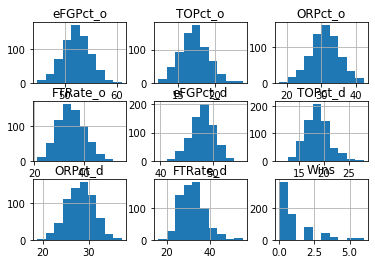

In [20]:
# histograms
final[final.columns[1:]].hist()
plt.show()

# Boxplots
Let's now take a look at boxplots of the predictor variables. Here we can see that the range for each predictor variable is relatively small, and it looks like there could potentially be some outliers.

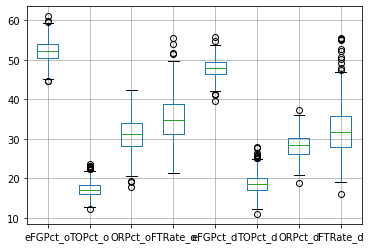

In [21]:
# boxplots of predictor variables
final[final.columns[1:10]].boxplot()
plt.show()

# Density plots
Let's take a look at density plots for both the predictor and response variables. This tells a similar story to the histograms, showing relative normality for each predictor variable. The response variable is once again most dense between the 0 and 1 values.

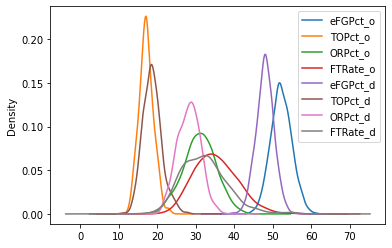

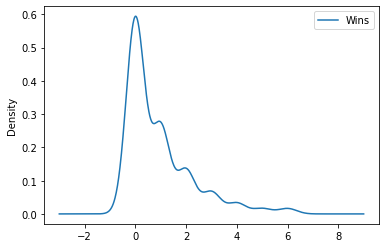

In [22]:
# density plot of predictor variables
final[final.columns[1:10]].plot.kde()
plt.show()

# density plot of response variable
final[final.columns[10:]].plot.kde()
plt.show()

# Scatterplots
Let's look at a few example scatterplots to see what the relationships between some of the predictor variables and the response variable looks like.
<br>
<br>
Having a higher effective field percentage on offense is good - it means that the team makes a higher percentage of their shots. We can see that generally teams that win more games in March Madness have higher effective field percentages on offense than teams that win less games.
<br>
<br>
On the flipside, having a lower effective field goal percentage on defense is good - it means that the team allows their opponent to make a lower percentage of their shots. As we would expect, teams with higher win totals generally seem to allow lower effective field goal percentages on defense.
<br>
<br>
Looking at offensive free throw rate, it does not appear to have much of a relationship with the response variable at all. Free throw rate is generally viewed as the least important of the four factors, so the lack of a relationship is not surprising.

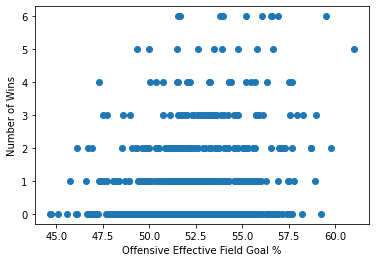

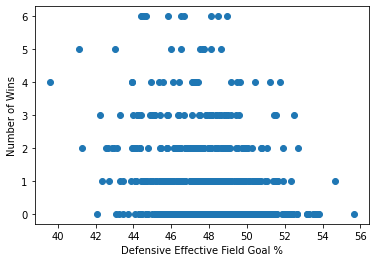

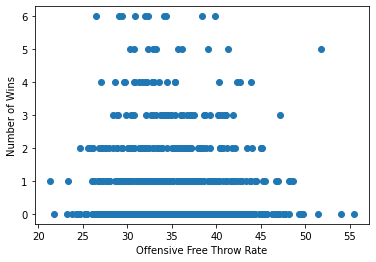

In [23]:
# scatterplot of offensive effective field goal percentage and wins
plt.scatter(final['eFGPct_o'], final['Wins'])
plt.xlabel('Offensive Effective Field Goal %')
plt.ylabel('Number of Wins')
plt.show()

# scatterplot of defensive effective field goal percentage and wins
plt.scatter(final['eFGPct_d'], final['Wins'])
plt.xlabel('Defensive Effective Field Goal %')
plt.ylabel('Number of Wins')
plt.show()

# scatterplot of offensive free throw rate and wins
plt.scatter(final['FTRate_o'], final['Wins'])
plt.xlabel('Offensive Free Throw Rate')
plt.ylabel('Number of Wins')
plt.show()

# Comparison: teams that won at least 4 games
Just for comparison's sake, let's create a subset of the dataset to only include teams that won 4 or more games in any given March Madness tournament. This will include all teams who made the 'Final Four', which is regarded as a huge accomplishment even if the team doesn't win the championship.
<br>
<br>
Looking at the summary statistics, we can see that the mean offensive effective field goal percentage is higher for this subset than for the overall dataset, and the mean defensive effective field goal percentage is lower - indicating that better teams tend to win more games in March Madness.

In [24]:
# create subset
four_wins = final[final['Wins'] >= 4].reset_index(drop=True)

# summary statistics for subset
print('Summary statistics for teams that won at least 4 games:')
display(four_wins.describe())

# summary statistics for overall dataset
print('Summary statistics for overall dataset:')
display(final.describe())

Summary statistics for teams that won at least 4 games:


,Season,eFGPct_o,TOPct_o,ORPct_o,FTRate_o,eFGPct_d,TOPct_d,ORPct_d,FTRate_d,Wins
count,40.00000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,2018.90000,53.948951,16.375918,32.838959,34.182733,46.684719,18.498968,28.083969,29.712638,4.750000
std,3.34204,2.862603,1.551798,4.396943,5.172514,2.484189,2.674251,2.926299,5.773442,0.839719
min,2014.00000,47.276995,12.366400,22.113503,26.511135,39.579400,13.618589,21.554054,19.049553,4.000000
25%,2016.00000,51.628130,15.641561,30.292528,30.789753,45.249800,16.943324,25.976383,26.120916,4.000000
50%,2018.50000,54.114567,16.379864,31.824189,32.814148,47.131079,18.238683,28.422969,28.255208,4.500000
75%,2022.00000,55.870519,17.360200,35.517750,35.836443,48.094808,19.537166,29.985782,31.601697,5.250000
max,2024.00000,61.017812,19.105166,41.916600,51.739700,51.724964,24.621755,35.276750,44.520189,6.000000


Summary statistics for overall dataset:


,Season,eFGPct_o,TOPct_o,ORPct_o,FTRate_o,eFGPct_d,TOPct_d,ORPct_d,FTRate_d,Wins
count,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000
mean,2018.900000,52.231558,17.201908,31.055055,35.203476,48.007831,18.704268,28.226395,32.236853,0.926471
std,3.302429,2.672808,1.873807,4.195409,5.547835,2.284524,2.442276,2.932518,5.917707,1.321803
min,2014.000000,44.641850,12.366400,17.734450,21.269541,39.579400,10.976428,18.805704,16.006885,0.000000
25%,2016.000000,50.434927,15.982590,28.307722,31.116790,46.539675,16.938174,26.080955,27.950973,0.000000
50%,2018.500000,52.129480,17.136050,31.178954,34.857332,48.056211,18.523462,28.392299,31.841208,0.000000
75%,2022.000000,54.023711,18.378039,33.905104,38.747767,49.557842,20.171225,30.312563,35.663550,1.000000
max,2024.000000,61.017812,23.723703,42.250674,55.470900,55.667800,27.982700,37.195634,55.500900,6.000000


# Build linear regression model
Time to build the linear regression model! I first defined the predictor variables as 'X', and defined the response variable as 'Y.' I then split the dataset into training (80%) and testing (20%) datasets using the train_test_split function from the sklearn package. I made sure to set a random seed for reproducibility.
<br>
<br>
I then used the add_constant function from the statsmodels package to add an intercept term to the model. Finally, I built the model using the OLS function from the statmodels package.
<br>
<br>
## Note: running the below code will produce a warning due to the functions used.

In [25]:
# create X and Y variables
X = final[['eFGPct_o', 'TOPct_o', 'ORPct_o', 'FTRate_o', 'eFGPct_d', 'TOPct_d', 'ORPct_d', 'FTRate_d']]
Y = final['Wins']

# split into train and test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=100)

# add intercept to model
X_train = sm.add_constant(X_train)

# build model
model1 = sm.OLS(Y_train, X_train).fit()

/usr/local/lib/python3.8/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  x = pd.concat(x[::order], 1)


# Model summary
Let's take a look at the model summary and note some interesting points.
- The number of observations is correctly 544 (680*0.8).
- The R-squared and Adjusted R-squared values are not very good - 0.261 and 0.25 respectively.
- The P-value on the overall model F-statistic is 4.36e-31, indicating that the model is statistically significant.
- Most of the predictor variables are statistically significant at the alpha=0.05 significance level. The only ones that are not are:
  - Intercept
  - Offensive free throw rate
  - Defensive offensive rebounding percentage
- The note at the bottom of the summary shows that multicollinearity could potentially be an issue in this model.

In [26]:
# model summary
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                   Wins   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                     23.62
Date:                Thu, 05 Dec 2024   Prob (F-statistic):           4.36e-31
Time:                        14:04:35   Log-Likelihood:                -824.43
No. Observations:                 544   AIC:                             1667.
Df Residuals:                     535   BIC:                             1706.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7936      1.869     -0.960      0.3

# Make predictions on test data
It's time to use the model we've built to make some predictions! I first made sure to add an intercept term to the testing data, and then used the predict function to make predictions using the linear regression model.
<br>
<br>
Calculating the mean squared error (MSE) and mean absolute error (MAE), we can see that our model did okay but not great. Specifically looking at the MAE since it's more intuitive to interpret: the value was 0.8653, which means that on average, the model incorrectly predicted the number of games that a team would win in March Madness by slightly less than 1 game. This may not seem like a huge difference, but considering that the vast majority of teams win either 0 or 1 games, I would want the model to be a little more accurate.
<br>
<br>
## Note: running the below code will produce a warning due to the functions used.

In [27]:
# add intercept and make predictions
X_test = sm.add_constant(X_test)
Y_pred = model1.predict(X_test)

# calculate MSE and MAE
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

Mean Squared Error: 1.6239
Mean Absolute Error: 0.8653


/usr/local/lib/python3.8/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  x = pd.concat(x[::order], 1)


# Closer look at predictions
Looking at the predicted values plotted against the actual win totals, we can see a few things:
- There are some predictions of less than 0 - this obviously could not happen in reality.
- Predicted values are not discrete as they would be in reality. This (and the negative predictions) are due to using linear regression rather than a classification technique that could predict discrete values.
- The predicted values are very low even for teams that won a lot of games in reality. In fact, looking at the maximum predicted value, we can see that it is 3.078.
  - The low predictions are likely again due to the fact that the bulk of the data is 0 or 1 win - when the response variable is not balanced, the predictions are more likely to be in the range of the majority.
- The average predicted wins is roughly the same as the average actual wins.

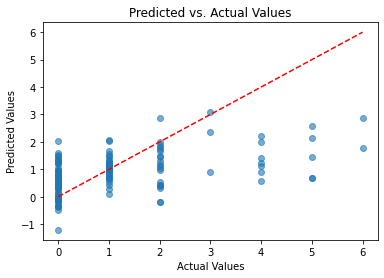

Maximum predicted value: 3.0780
Average predicted value: 0.8757
Average number of actual wins from dataset: 0.9265


In [28]:
# note that there are negative predictions, and predictions are not integers like they would be in reality
# predictions are pretty low, looks like there were no predictions greater than 3.5 or so
plt.scatter(Y_test, Y_pred, alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linestyle='--')
plt.title("Predicted vs. Actual Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

# max and mean predicted values, mean actual values
print(f"Maximum predicted value: {Y_pred.max():.4f}")
print(f"Average predicted value: {Y_pred.mean():.4f}")
print(f"Average number of actual wins from dataset: {final['Wins'].mean():.4f}")

# Feature importance
Lastly, let's visualize which predictors were the most important in terms of predicting the response variable in the linear regression model.
<br>
<br>
Based on the magnitude of the coefficients on each predictor, it seems as though the most important predictors were:
- Offensive turnover percentage
- Offensive effective field goal percentage
- Defensive effective field goal percentage

While turnover percentage is thought of as being important, I am surprised that it had the largest coefficient. Note that the coefficient is negative because turning the ball over on offense is a bad thing - so less turnovers would generally equate to more wins.

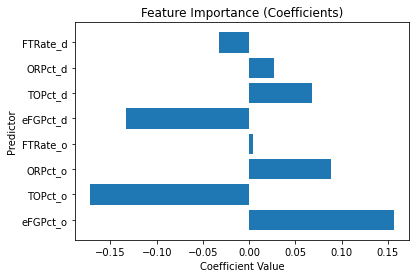

In [29]:
# strip out coefficients and predictors, excluding the intercept
coefficients = model1.params[1:]
predictors = X.columns

# plot coefficients
plt.barh(predictors, coefficients)
plt.title("Feature Importance (Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Predictor")
plt.show()

# Conclusions
Relating the analysis back to my two original research questions:

1) How well can KenPom's four factors data predict how many games a team will win in March Madness?

While the model seemed to do an okay job of making predictions, I would say that based on the R-squared of the model along with the MAE that the model that it is difficult to make accurate predictions for how many games a team will win in March Madness using a linear regression model with KenPom's four factors.

2) Which of the four factors are most important in predicting March Madness success?

Based on the model, offensive turnover percentage is the most important predictor variable among the four factor data, followed by offensive effective field goal percentage and defensive effective field goal percentage.

# Future work
There are many opportunities for future work to improve on this analysis.
- Use models other than linear regression. I would like to try using a classification technique to be able to make discrete predictions.
- Use data that is more balanced in the response variable. The model that I built had trouble with teams that won several games in March Madness due to the majority of the teams in the data having 0 or 1 wins.
- Use cross-validation to build a model based on multiple train-test data splits.
- Try scaling predictor variables. Although the predictor variables were on similar scales, they were a bit different, which can affect a linear regression model.
- Address potential multicollinearity by performing feature selection.
- Try predicting wins in March Madness using data other than KenPom's four factors.